In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data_1 = pd.read_csv("/content/drive/MyDrive/Grad project/dataset_v4_master_training.csv", low_memory=False)
data_1.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,flow_duration,total_packets,total_bytes,avg_packet_size,...,arp_reply_rate,arp_request_rate,arp_reply_request_ratio,arp_gratuitous_count,arp_unsolicited_count,mac_ip_binding_changes,ip_mac_binding_changes,label,attack_type,snort_sid
0,2026-06-20T21:29:32.987864,10.0.0.3,10.0.0.4,0,0,ARP,0.0049,4,168,42.0,...,0.0000,4041.7287,0.0000,0.0,0.0,0.0,0.0,0.0,normal,none
1,2026-06-20T21:29:32.989954,10.0.0.4,10.0.0.3,0,0,ARP,0.0025,2,84,42.0,...,810.8069,6486.4551,0.1176,0.0,0.0,0.0,0.0,0.0,normal,none
2,2026-06-20T21:29:32.992616,10.0.0.3,10.0.0.4,0,0,ICMP,0.0961,3,294,98.0,...,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,normal,none
3,2026-06-20T21:29:32.995119,10.0.0.4,10.0.0.3,0,0,ICMP,0.0934,2,196,98.0,...,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,normal,none
4,2026-06-20T21:29:33.015020,10.0.0.3,10.0.0.5,0,0,ARP,0.0069,4,168,42.0,...,0.0000,2901.2271,0.0000,0.0,0.0,0.0,0.0,0.0,normal,none


#Data preprocessing

In [ ]:
data_1["label"].value_counts()

,count
label,
0.0,54234
2.0,3780
1.0,220


In [ ]:
data_1_noAttacks = data_1[~data_1['label'].isin([1, 2])]
data_1_noAttacks["label"].value_counts()

,count
label,
0.0,54234


In [ ]:
feature_dict = data_1_noAttacks.columns.tolist()
print(len(feature_dict))
feature_dict

94


['timestamp',
 'src_ip',
 'dst_ip',
 'src_port',
 'dst_port',
 'protocol',
 'flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential

In [ ]:
features_to_drop = [
  'timestamp',
  'src_ip',
  'dst_ip',
  'src_port',
  'dst_port',
  'top_dst_port',
  'snort_sid',
  'active_snort_alerts',
  'distinct_alert_types',
]
data_1_noAttacks = data_1_noAttacks.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict = data_1_noAttacks.columns.tolist()
print(len(feature_dict))
feature_dict

85


['protocol',
 'flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'is_broadcast_dst',
 'flows_per_window',
 'device_total_flows',


In [ ]:
#Dropping unneeded features
features_to_drop = [
  "incomplete_ratio",
  "packets_per_second",
  "total_bytes",
  "device_pkt_rate_deviation",
  "is_broadcast_dst",
  "arp_reply_request_ratio",
  "device_byte_rate_deviation",
  "arp_gratuitous_count",
  "inter_arrival_std",
  "is_registered_iot",
  "ip_mac_binding_changes",
  "rst_count",
  "arp_unsolicited_count",
  "well_known_port_ratio",
  "device_pkt_rate_deviation",
  "burst_duration_avg",
  "broadcast_ratio",
  "arp_reply_rate",
  "burst_count",
  "psh_count",
  "device_unique_dst_ips",
 "mac_ip_binding_changes",
  "device_avg_byte_rate",
  "device_age_seconds",
  "network_avg_flow_duration",
  "inter_arrival_max",
  "dst_port_std",
  "inter_arrival_min",

]
data_1_noAttacks = data_1_noAttacks.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict = data_1_noAttacks.columns.tolist()
print(len(feature_dict))
feature_dict

58


['protocol',
 'flow_duration',
 'total_packets',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_cv',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'flows_per_window',
 'device_total_flows',
 'device_avg_pkt_rate',
 'device_unique_dst_ports',
 'device_new_dst_ratio',
 'device_protocol_dist_tcp',
 'device_protocol_dist_udp',
 'device_protocol_dist_icmp',
 'device_avg_payload_size',
 'device_payload_size_deviation',
 'is_gateway',
 'is_baseline_m

##One Hot Encoder

In [ ]:
data_1_noAttacks_encoded = pd.get_dummies(data_1_noAttacks, prefix='protocol')
data_1_noAttacks_encoded.head()

,flow_duration,total_packets,avg_packet_size,min_packet_size,max_packet_size,bytes_per_second,syn_count,ack_count,fin_count,unique_src_ports,...,network_entropy_dst_port,multicast_ratio,arp_broadcast_ratio,arp_request_rate,label,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP,protocol_normal
0,0.0049,4,42.0,42,42,33950.5214,0,0,0,0,...,0.0,0.0,0.5769,4041.7287,0.0,True,False,False,False,True
1,0.0025,2,42.0,42,42,34053.8890,0,0,0,0,...,0.0,0.0,0.5769,6486.4551,0.0,True,False,False,False,True
2,0.0961,3,98.0,98,98,3060.5024,0,0,0,0,...,0.0,0.0,0.5769,0.0000,0.0,False,True,False,False,True
3,0.0934,2,98.0,98,98,2097.8852,0,0,0,0,...,0.0,0.0,0.5769,0.0000,0.0,False,True,False,False,True
4,0.0069,4,42.0,42,42,24370.3075,0,0,0,0,...,0.0,0.0,0.5769,2901.2271,0.0,True,False,False,False,True


##Splitting Data

In [ ]:
x = data_1_noAttacks_encoded.drop('label', axis=1)
x = x.drop('attack_type', axis=1 , errors = "ignore")
y = data_1_noAttacks_encoded['label']
print(len(x.columns.tolist()))
print(x.columns.tolist())
print(y.value_counts())
x

60
['flow_duration', 'total_packets', 'avg_packet_size', 'min_packet_size', 'max_packet_size', 'bytes_per_second', 'syn_count', 'ack_count', 'fin_count', 'unique_src_ports', 'unique_dst_ports', 'inter_arrival_mean', 'inter_arrival_cv', 'fwd_packet_count', 'bwd_packet_count', 'fwd_bwd_packet_ratio', 'fwd_bwd_bytes_ratio', 'fwd_avg_packet_size', 'bwd_avg_packet_size', 'reply_rate', 'syn_ack_ratio', 'completed_sessions', 'avg_session_duration', 'payload_size_entropy', 'src_port_entropy', 'icmp_type_entropy', 'pkt_size_std', 'pkt_size_variance', 'small_pkt_ratio', 'large_pkt_ratio', 'top_dst_port_ratio', 'ephemeral_port_ratio', 'sequential_port_score', 'flows_per_window', 'device_total_flows', 'device_avg_pkt_rate', 'device_unique_dst_ports', 'device_new_dst_ratio', 'device_protocol_dist_tcp', 'device_protocol_dist_udp', 'device_protocol_dist_icmp', 'device_avg_payload_size', 'device_payload_size_deviation', 'is_gateway', 'is_baseline_mature', 'network_active_flows', 'network_total_pps', '

,flow_duration,total_packets,avg_packet_size,min_packet_size,max_packet_size,bytes_per_second,syn_count,ack_count,fin_count,unique_src_ports,...,network_entropy_src_ip,network_entropy_dst_port,multicast_ratio,arp_broadcast_ratio,arp_request_rate,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP,protocol_normal
0,0.0049,4,42.0,42,42,33950.5214,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,4041.7287,True,False,False,False,True
1,0.0025,2,42.0,42,42,34053.8890,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,6486.4551,True,False,False,False,True
2,0.0961,3,98.0,98,98,3060.5024,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,0.0000,False,True,False,False,True
3,0.0934,2,98.0,98,98,2097.8852,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,0.0000,False,True,False,False,True
4,0.0069,4,42.0,42,42,24370.3075,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,2901.2271,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58230,0.0010,1,54.0,54,54,54000.0000,0,1,0,1,...,2.0919,8.0491,0.0,0.0000,0.0000,False,False,True,False,True
58231,0.0010,1,54.0,54,54,54000.0000,0,1,0,1,...,2.0919,8.0491,0.0,0.0000,0.0000,False,False,True,False,True
58232,0.0010,1,54.0,54,54,54000.0000,0,1,0,1,...,2.0919,8.0491,0.0,0.0000,0.0000,False,False,True,False,True
58233,0.0010,1,54.0,54,54,54000.0000,0,1,0,1,...,2.0919,8.0491,0.0,0.0000,0.0000,False,False,True,False,True


##Standarized Data


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit and transform, then create DataFrame, explicitly assigning the original index from x
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns, index=x.index)

# Now, identify and remove rows with NaN values from x_scaled and y, which now share the same index
nan_rows_after_scaling = x_scaled.isnull().any(axis=1) | y.isnull()

if nan_rows_after_scaling.any():
    print(f"Found {nan_rows_after_scaling.sum()} rows with NaN values in x_scaled or y after scaling. Dropping them.")
    x_scaled = x_scaled[~nan_rows_after_scaling]
    y = y[~nan_rows_after_scaling]

x_scaled

Found 1 rows with NaN values in x_scaled or y after scaling. Dropping them.


,flow_duration,total_packets,avg_packet_size,min_packet_size,max_packet_size,bytes_per_second,syn_count,ack_count,fin_count,unique_src_ports,...,network_entropy_src_ip,network_entropy_dst_port,multicast_ratio,arp_broadcast_ratio,arp_request_rate,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP,protocol_normal
0,-0.327918,-0.163976,-0.255240,-0.273586,-0.301613,-0.164577,-0.047657,-0.130332,-0.261853,-0.028878,...,1.581279,-1.865311,0.0,6.392437,10.277196,5.387992,-0.319166,-2.355869,-0.166327,0.004294
1,-0.330076,-0.165237,-0.255240,-0.273586,-0.301613,-0.164396,-0.047657,-0.130332,-0.261853,-0.028878,...,1.581279,-1.865311,0.0,6.392437,16.564339,5.387992,-0.319166,-2.355869,-0.166327,0.004294
2,-0.245905,-0.164606,0.030514,0.361511,-0.053378,-0.218746,-0.047657,-0.130332,-0.261853,-0.028878,...,1.581279,-1.865311,0.0,6.392437,-0.116984,-0.185598,3.133163,-2.355869,-0.166327,0.004294
3,-0.248333,-0.165237,0.030514,0.361511,-0.053378,-0.220434,-0.047657,-0.130332,-0.261853,-0.028878,...,1.581279,-1.865311,0.0,6.392437,-0.116984,-0.185598,3.133163,-2.355869,-0.166327,0.004294
4,-0.326119,-0.163976,-0.255240,-0.273586,-0.301613,-0.181377,-0.047657,-0.130332,-0.261853,-0.028878,...,1.581279,-1.865311,0.0,6.392437,7.344149,5.387992,-0.319166,-2.355869,-0.166327,0.004294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58229,-0.331425,-0.165867,-0.173596,-0.092129,-0.230688,-0.122404,-0.044925,-0.129369,-0.261853,-0.027180,...,0.705123,0.818940,0.0,-0.124740,-0.116984,-0.185598,-0.319166,0.424472,-0.166327,0.004294
58230,-0.331425,-0.165867,-0.194007,-0.137494,-0.248419,-0.129418,-0.047657,-0.129369,-0.261853,-0.027180,...,0.705123,0.818940,0.0,-0.124740,-0.116984,-0.185598,-0.319166,0.424472,-0.166327,0.004294
58231,-0.331425,-0.165867,-0.194007,-0.137494,-0.248419,-0.129418,-0.047657,-0.129369,-0.261853,-0.027180,...,0.705123,0.818940,0.0,-0.124740,-0.116984,-0.185598,-0.319166,0.424472,-0.166327,0.004294
58232,-0.331425,-0.165867,-0.194007,-0.137494,-0.248419,-0.129418,-0.047657,-0.129369,-0.261853,-0.027180,...,0.705123,0.818940,0.0,-0.124740,-0.116984,-0.185598,-0.319166,0.424472,-0.166327,0.004294


## Splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (43387, 60)
X_val shape: (10847, 60)
y_train shape: (43387,)
y_val shape: (10847,)


#Model training

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Define the input dimension based on X_train shape
input_dim = X_train.shape[1]
latent_dim = 32 # Dimension of the latent space

# Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation='relu')(input_layer)
encoder = Dense(latent_dim, activation='relu')(encoder)

# Decoder
decoder = Dense(64, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder) # Linear activation for scaled data

# Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile the autoencoder with a reduced learning rate to prevent numerical instability
autoencoder.compile(optimizer=Adam(learning_rate=0.0001), loss='mse')

# Display the model summary
autoencoder.summary()

print("Autoencoder model architecture defined and compiled.")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 60)             │         3,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,996 (46.86 KB)

 Trainable params: 11,996 (46.86 KB)

 Non-trainable params: 0 (0.00 B)

Autoencoder model architecture defined and compiled.


In [ ]:
# Train the autoencoder
history = autoencoder.fit(X_train, X_train, # Input and target are the same for autoencoders
                          epochs=50, #################Change and check
                          batch_size=128,
                          shuffle=True,
                          validation_data=(X_val, X_val),
                          verbose=0) # Set verbose to 1 or 2 for progress output

print("Autoencoder training complete.")
# Can access training loss via history.history['loss']
# And validation loss via history.history['val_loss']

Autoencoder training complete.


339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
95th percentile reconstruction error (threshold): 0.0974
99th percentile reconstruction error (threshold): 0.2394


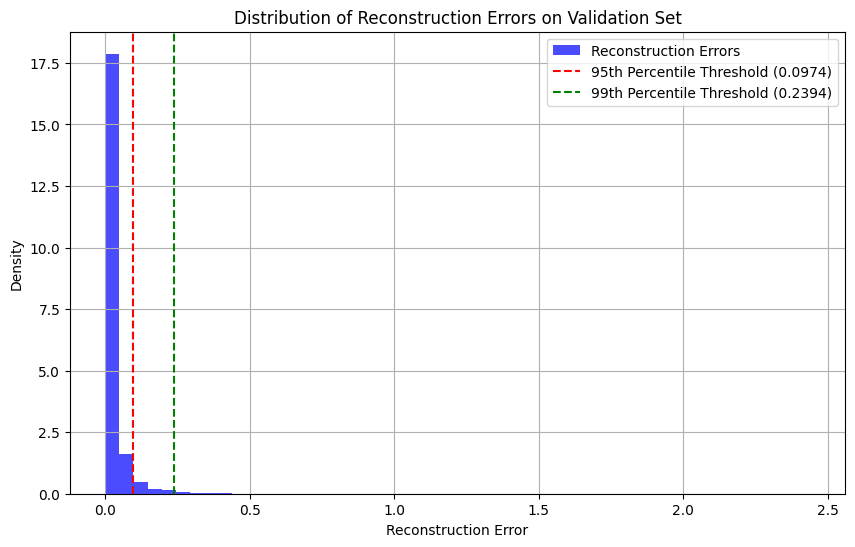

In [ ]:
# Calculate reconstruction errors on the validation set
X_val_reconstructed = autoencoder.predict(X_val)
reconstruction_errors = np.mean(np.square(X_val - X_val_reconstructed), axis=1)

# Determine an anomaly threshold (e.g., 95th or 99th percentile of reconstruction errors)
threshold_95_percentile = np.percentile(reconstruction_errors, 95)
threshold_99_percentile = np.percentile(reconstruction_errors, 99)

print(f"95th percentile reconstruction error (threshold): {threshold_95_percentile:.4f}")
print(f"99th percentile reconstruction error (threshold): {threshold_99_percentile:.4f}")

# Optionally, visualize the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors, bins=50, density=True, alpha=0.7, color='blue', label='Reconstruction Errors')
plt.axvline(threshold_95_percentile, color='red', linestyle='--', label=f'95th Percentile Threshold ({threshold_95_percentile:.4f})')
plt.axvline(threshold_99_percentile, color='green', linestyle='--', label=f'99th Percentile Threshold ({threshold_99_percentile:.4f})')
plt.title('Distribution of Reconstruction Errors on Validation Set')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Load the original full dataset for evaluation (including attacks)
data_full_evaluation = data_1.copy()

# Apply the same preprocessing steps as the training data
# Drop irrelevant features first
features_to_drop_stage1 = [
  'timestamp',
  'src_ip',
  'dst_ip',
  'src_port',
  'dst_port',
  'top_dst_port',
  'snort_sid',
  'active_snort_alerts',
  'distinct_alert_types',
]
data_full_evaluation = data_full_evaluation.drop(columns=features_to_drop_stage1, axis=1, errors='ignore')

# Drop other selected features
features_to_drop_stage2 = [
  "incomplete_ratio",
  "packets_per_second",
  "total_bytes",
  "device_pkt_rate_deviation",
  "is_broadcast_dst",
  "arp_reply_request_ratio",
  "device_byte_rate_deviation",
  "arp_gratuitous_count",
  "inter_arrival_std",
  "is_registered_iot",
  "ip_mac_binding_changes",
  "rst_count",
  "arp_unsolicited_count",
  "well_known_port_ratio",
  "device_pkt_rate_deviation", # Duplicate entry, keeping for consistency with previous cell
  "burst_duration_avg",
  "broadcast_ratio",
  "arp_reply_rate",
  "burst_count",
  "psh_count",
  "device_unique_dst_ips",
  "mac_ip_binding_changes",
  "device_avg_byte_rate",
  "device_age_seconds",
  "network_avg_flow_duration",
  "inter_arrival_max",
  "dst_port_std",
  "inter_arrival_min",
]
data_full_evaluation = data_full_evaluation.drop(columns=features_to_drop_stage2, axis=1, errors='ignore')

# One-hot encode the 'protocol' column
data_full_evaluation_encoded = pd.get_dummies(data_full_evaluation, prefix='protocol')

# Separate features (X_full) and original labels (y_full_raw)
X_full = data_full_evaluation_encoded.drop(['label', 'attack_type'], axis=1, errors='ignore')
y_full_raw = data_full_evaluation_encoded['label']

# Align columns of X_full with x (the DataFrame used to fit the scaler)
# This is crucial because pd.get_dummies might produce different columns if categories differ
missing_cols_in_full = set(x.columns) - set(X_full.columns)
for c in missing_cols_in_full:
    X_full[c] = 0
# Ensure the order of columns is the same as x
X_full = X_full[x.columns]

# Scale the full dataset using the *same* scaler fitted on the training data
X_full_scaled = pd.DataFrame(scaler.transform(X_full), columns=X_full.columns, index=X_full.index)

# Handle NaNs in the full dataset (should align with training data)
nan_rows_full = X_full_scaled.isnull().any(axis=1) | y_full_raw.isnull()

if nan_rows_full.any():
    print(f"Found {nan_rows_full.sum()} rows with NaN values in X_full_scaled or y_full_raw. Dropping them.")
    X_full_scaled = X_full_scaled[~nan_rows_full]
    y_full_raw = y_full_raw[~nan_rows_full]

# Create binary labels for evaluation (0 for normal, 1 for attack)
y_full_binary = (y_full_raw != 0).astype(int)


print(f"Shape of X_full_scaled: {X_full_scaled.shape}")
print(f"Shape of y_full_binary: {y_full_binary.shape}")
print("Class distribution in full dataset (binary labels):\n", y_full_binary.value_counts())


Found 1 rows with NaN values in X_full_scaled or y_full_raw. Dropping them.
Shape of X_full_scaled: (58234, 60)
Shape of y_full_binary: (58234,)
Class distribution in full dataset (binary labels):
 label
0    54234
1     4000
Name: count, dtype: int64


1820/1820 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion Matrix:
[[53678   556]
 [    0  4000]]
Precision: 0.8780
Recall: 1.0000
F1-Score: 0.9350


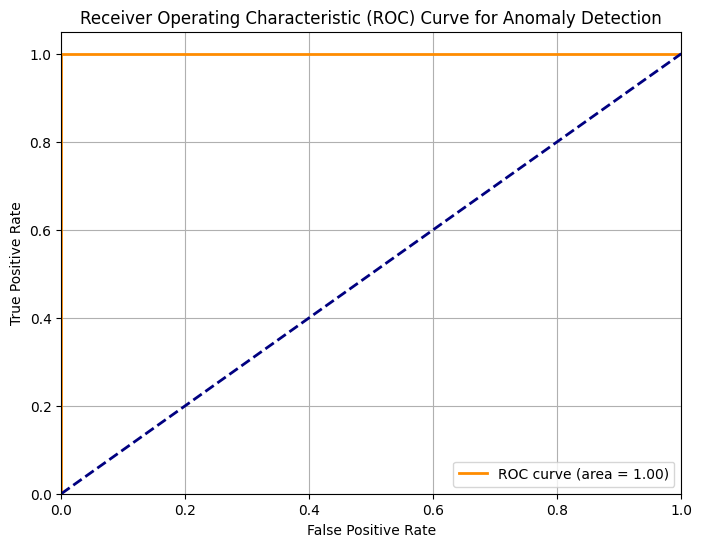

ROC AUC: 1.0000


In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc

# Get reconstruction errors for the entire dataset
X_full_reconstructed = autoencoder.predict(X_full_scaled)
reconstruction_errors_full = np.mean(np.square(X_full_scaled - X_full_reconstructed), axis=1)

# Apply the 99th percentile threshold (or choose another based on desired sensitivity/specificity)
threshold = threshold_99_percentile # Using the threshold derived from the validation set

# Classify instances as normal (0) or anomaly (1) based on the threshold
# If reconstruction error > threshold, it's an anomaly (1)
predictions_full = (reconstruction_errors_full > threshold).astype(int)

# Evaluate performance
# Confusion Matrix
cm = confusion_matrix(y_full_binary, predictions_full)
print("Confusion Matrix:")
print(cm)

# Precision, Recall, F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_full_binary, predictions_full, average='binary')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_full_binary, reconstruction_errors_full)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Anomaly Detection')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

## Model Evaluation (Autoencoder)

Anomaly Threshold (95th percentile from validation set): 0.2394

--- Classification Report on Full Dataset (95th percentile threshold) ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     54234
     Anomaly       0.88      1.00      0.94      4000

    accuracy                           0.99     58234
   macro avg       0.94      0.99      0.96     58234
weighted avg       0.99      0.99      0.99     58234


--- Confusion Matrix on Full Dataset (95th percentile threshold) ---
[[53678   556]
 [    0  4000]]


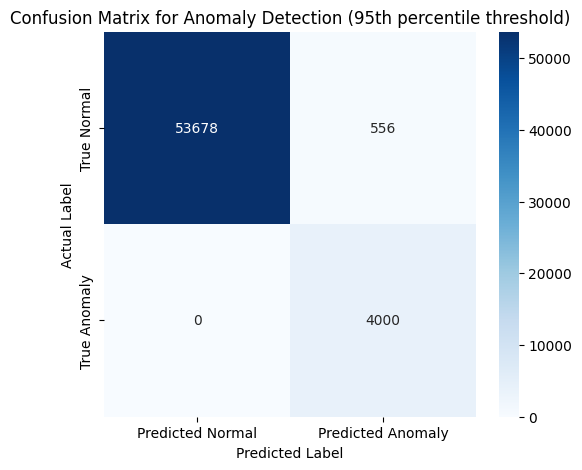


--- Sweeping different percentile thresholds (based on validation set) ---
P90 | threshold=0.0596 | precision=0.422 | recall=1.000
P92 | threshold=0.0722 | precision=0.480 | recall=1.000
P95 | threshold=0.0974 | precision=0.597 | recall=1.000
P97 | threshold=0.1398 | precision=0.725 | recall=1.000
P99 | threshold=0.2394 | precision=0.878 | recall=1.000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define anomaly threshold (using the 99th percentile from validation data)
anomaly_threshold = threshold_99_percentile

# Classify full dataset based on the threshold
# predictions_full was already calculated in the previous cell using threshold_99_percentile
# Let's recalculate if we want to use anomaly_threshold (95th percentile)
predictions_full_95pct = (reconstruction_errors_full > anomaly_threshold).astype(int)

print(f"Anomaly Threshold (95th percentile from validation set): {anomaly_threshold:.4f}")

print("\n--- Classification Report on Full Dataset (95th percentile threshold) ---")
print(classification_report(y_full_binary, predictions_full_95pct, target_names=['Normal', 'Anomaly']))

print("\n--- Confusion Matrix on Full Dataset (95th percentile threshold) ---")
conf_matrix = confusion_matrix(y_full_binary, predictions_full_95pct)
print(conf_matrix)

# Optional: Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['True Normal', 'True Anomaly'])
plt.title('Confusion Matrix for Anomaly Detection (95th percentile threshold)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- Sweeping different percentile thresholds (based on validation set) ---")
for pct in [90, 92, 95, 97, 99]:
    # Use the reconstruction errors from the *validation* data to set the threshold
    threshold_current_pct = np.percentile(reconstruction_errors, pct)
    # Apply this threshold to the reconstruction errors of the *full dataset*
    preds_current_pct = (reconstruction_errors_full > threshold_current_pct).astype(int)
    recall = recall_score(y_full_binary, preds_current_pct)
    precision = precision_score(y_full_binary, preds_current_pct)
    print(f"P{pct} | threshold={threshold_current_pct:.4f} | precision={precision:.3f} | recall={recall:.3f}")

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

# Using existing variables from previous cells
# X_full_scaled: the scaled full dataset
# y_full_binary: the binary labels for the full dataset
# autoencoder: the trained autoencoder model
# anomaly_threshold: the 95th percentile threshold from validation data

n_splits = 20 # Number of folds for cross-validation
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
precision_scores = []
recall_scores = []
f1_scores = []

print(f"Performing {n_splits}-fold cross-validation on the full dataset...")

# To handle the imbalanced dataset for StratifiedKFold, we need to make sure
# the minority class (anomalies) is present in each fold. The user's provided
# code directly uses skf.split(mixed_traffic_scaled_df, y_true_mixed_traffic)
# which assumes y_true_mixed_traffic is suitable for stratification.
# In our case, y_full_binary contains both 0s (normal) and 1s (anomaly).
# StratifiedKFold will work correctly here if each fold has at least one instance of each class.

for fold, (train_idx_cv, test_idx_cv) in enumerate(skf.split(X_full_scaled, y_full_binary)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    X_test_fold = X_full_scaled.iloc[test_idx_cv]
    y_test_fold = y_full_binary.iloc[test_idx_cv]

    # Predict reconstructions for the current test fold using the already trained autoencoder
    # verbose=0 to suppress per-batch output
    X_test_reconstructed_fold = autoencoder.predict(X_test_fold, verbose=0)

    # Calculate reconstruction errors for the test fold
    reconstruction_errors_fold = np.mean(np.square(X_test_fold - X_test_reconstructed_fold), axis=1)

    # Apply the pre-determined anomaly threshold (using anomaly_threshold, which is 95th percentile from validation)
    predictions_fold = (reconstruction_errors_fold > anomaly_threshold).astype(int)

    # Calculate and store metrics
    precision = precision_score(y_test_fold, predictions_fold)
    recall = recall_score(y_test_fold, predictions_fold)
    f1 = f1_score(y_test_fold, predictions_fold)
    conf_matrix = confusion_matrix(y_test_fold, predictions_fold)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

# Print average metrics across all folds
print("\n--- Average Metrics Across All Folds ---")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Performing 20-fold cross-validation on the full dataset...

--- Fold 1/20 ---
Precision: 0.8889
Recall: 1.0000
F1-Score: 0.9412
Confusion Matrix:
[[2687   25]
 [   0  200]]

--- Fold 2/20 ---
Precision: 0.8734
Recall: 1.0000
F1-Score: 0.9324
Confusion Matrix:
[[2683   29]
 [   0  200]]

--- Fold 3/20 ---
Precision: 0.8547
Recall: 1.0000
F1-Score: 0.9217
Confusion Matrix:
[[2678   34]
 [   0  200]]

--- Fold 4/20 ---
Precision: 0.8547
Recall: 1.0000
F1-Score: 0.9217
Confusion Matrix:
[[2678   34]
 [   0  200]]

--- Fold 5/20 ---
Precision: 0.8969
Recall: 1.0000
F1-Score: 0.9456
Confusion Matrix:
[[2689   23]
 [   0  200]]

--- Fold 6/20 ---
Precision: 0.8621
Recall: 1.0000
F1-Score: 0.9259
Confusion Matrix:
[[2680   32]
 [   0  200]]

--- Fold 7/20 ---
Precision: 0.8547
Recall: 1.0000
F1-Score: 0.9217
Confusion Matrix:
[[2678   34]
 [   0  200]]

--- Fold 8/20 ---
Precision: 0.9009
Recall: 1.0000
F1-Score: 0.9479
Confusion Matrix:
[[2690   22]
 [   0  200]]

--- Fold 9/20 ---
Precision:

##Model training with tighter bottleneck (16 units)

---



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Define the input dimension based on X_train shape
input_dim = X_train.shape[1]
latent_dim_tighter = 16 # Tighter bottleneck dimension

# Encoder for the tighter bottleneck autoencoder
input_layer_tighter = Input(shape=(input_dim,))
encoder_tighter = Dense(64, activation='relu')(input_layer_tighter)
encoder_tighter = Dense(latent_dim_tighter, activation='relu')(encoder_tighter)

# Decoder for the tighter bottleneck autoencoder
decoder_tighter = Dense(64, activation='relu')(encoder_tighter)
decoder_tighter = Dense(input_dim, activation='linear')(decoder_tighter)

# Tighter Bottleneck Autoencoder Model
autoencoder_tighter = Model(inputs=input_layer_tighter, outputs=decoder_tighter)

# Compile the autoencoder with a reduced learning rate
autoencoder_tighter.compile(optimizer=Adam(learning_rate=0.0001), loss='mse')

# Display the model summary
autoencoder_tighter.summary()

print("Tighter bottleneck autoencoder model architecture defined and compiled.")

# Train the tighter bottleneck autoencoder
history_tighter = autoencoder_tighter.fit(X_train, X_train, # Input and target are the same for autoencoders
                                        epochs=50,
                                        batch_size=128,
                                        shuffle=True,
                                        validation_data=(X_val, X_val),
                                        verbose=0) # Set verbose to 1 or 2 for progress output

print("Tighter bottleneck autoencoder training complete.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 60)             │         3,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,932 (38.80 KB)

 Trainable params: 9,932 (38.80 KB)

 Non-trainable params: 0 (0.00 B)

Tighter bottleneck autoencoder model architecture defined and compiled.
Tighter bottleneck autoencoder training complete.


In [ ]:
history_tighter = autoencoder_tighter.fit(X_train, X_train, # Input and target are the same for autoencoders
                                        epochs=50,
                                        batch_size=128,
                                        shuffle=True,
                                        validation_data=(X_val, X_val),
                                        verbose=0) # Set verbose to 1 or 2 for progress output

print("Tighter bottleneck autoencoder training complete.")

Tighter bottleneck autoencoder training complete.


95th percentile reconstruction error (tighter bottleneck threshold): 0.1750
99th percentile reconstruction error (tighter bottleneck threshold): 0.4044


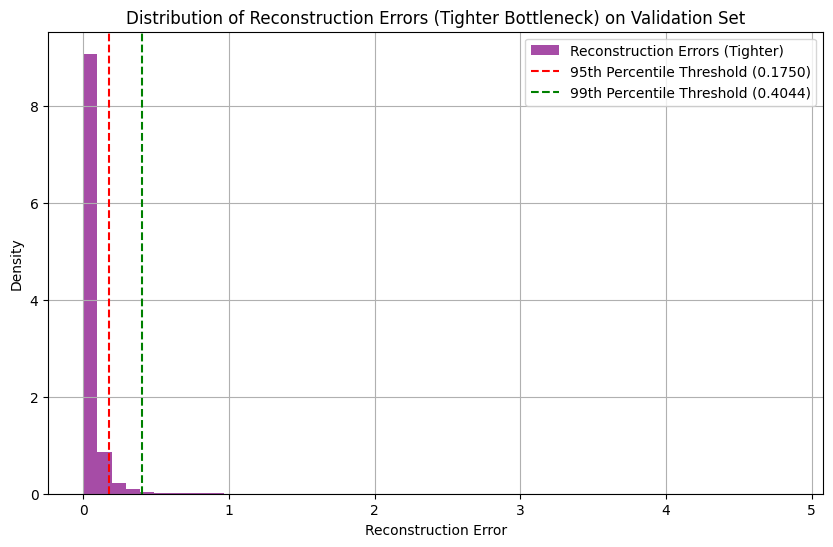

In [ ]:
# Calculate reconstruction errors on the validation set for the tighter bottleneck autoencoder
X_val_reconstructed_tighter = autoencoder_tighter.predict(X_val, verbose=0)
reconstruction_errors_tighter = np.mean(np.square(X_val - X_val_reconstructed_tighter), axis=1)

# Determine anomaly thresholds (e.g., 95th or 99th percentile of reconstruction errors)
threshold_95_percentile_tighter = np.percentile(reconstruction_errors_tighter, 95)
threshold_99_percentile_tighter = np.percentile(reconstruction_errors_tighter, 99)

print(f"95th percentile reconstruction error (tighter bottleneck threshold): {threshold_95_percentile_tighter:.4f}")
print(f"99th percentile reconstruction error (tighter bottleneck threshold): {threshold_99_percentile_tighter:.4f}")

# Optionally, visualize the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors_tighter, bins=50, density=True, alpha=0.7, color='purple', label='Reconstruction Errors (Tighter)')
plt.axvline(threshold_95_percentile_tighter, color='red', linestyle='--', label=f'95th Percentile Threshold ({threshold_95_percentile_tighter:.4f})')
plt.axvline(threshold_99_percentile_tighter, color='green', linestyle='--', label=f'99th Percentile Threshold ({threshold_99_percentile_tighter:.4f})')
plt.title('Distribution of Reconstruction Errors (Tighter Bottleneck) on Validation Set')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Load the original full dataset for evaluation (including attacks)
data_full_evaluation = data_1.copy()

# Apply the same preprocessing steps as the training data
# Drop irrelevant features first
features_to_drop_stage1 = [
  'timestamp',
  'src_ip',
  'dst_ip',
  'src_port',
  'dst_port',
  'top_dst_port',
  'snort_sid',
  'active_snort_alerts',
  'distinct_alert_types',
]
data_full_evaluation = data_full_evaluation.drop(columns=features_to_drop_stage1, axis=1, errors='ignore')

# Drop other selected features
features_to_drop_stage2 = [
  "incomplete_ratio",
  "packets_per_second",
  "total_bytes",
  "device_pkt_rate_deviation",
  "is_broadcast_dst",
  "arp_reply_request_ratio",
  "device_byte_rate_deviation",
  "arp_gratuitous_count",
  "inter_arrival_std",
  "is_registered_iot",
  "ip_mac_binding_changes",
  "rst_count",
  "arp_unsolicited_count",
  "well_known_port_ratio",
  "device_pkt_rate_deviation", # Duplicate entry, keeping for consistency with previous cell
  "burst_duration_avg",
  "broadcast_ratio",
  "arp_reply_rate",
  "burst_count",
  "psh_count",
  "device_unique_dst_ips",
  "mac_ip_binding_changes",
  "device_avg_byte_rate",
  "device_age_seconds",
  "network_avg_flow_duration",
  "inter_arrival_max",
  "dst_port_std",
  "inter_arrival_min",
]
data_full_evaluation = data_full_evaluation.drop(columns=features_to_drop_stage2, axis=1, errors='ignore')

# One-hot encode the 'protocol' column
data_full_evaluation_encoded = pd.get_dummies(data_full_evaluation, prefix='protocol')

# Separate features (X_full) and original labels (y_full_raw)
X_full = data_full_evaluation_encoded.drop(['label', 'attack_type'], axis=1, errors='ignore')
y_full_raw = data_full_evaluation_encoded['label']

# Align columns of X_full with x (the DataFrame used to fit the scaler)
# This is crucial because pd.get_dummies might produce different columns if categories differ
missing_cols_in_full = set(x.columns) - set(X_full.columns)
for c in missing_cols_in_full:
    X_full[c] = 0
# Ensure the order of columns is the same as x
X_full = X_full[x.columns]

# Scale the full dataset using the *same* scaler fitted on the training data
X_full_scaled = pd.DataFrame(scaler.transform(X_full), columns=X_full.columns, index=X_full.index)

# Handle NaNs in the full dataset (should align with training data)
nan_rows_full = X_full_scaled.isnull().any(axis=1) | y_full_raw.isnull()

if nan_rows_full.any():
    print(f"Found {nan_rows_full.sum()} rows with NaN values in X_full_scaled or y_full_raw. Dropping them.")
    X_full_scaled = X_full_scaled[~nan_rows_full]
    y_full_raw = y_full_raw[~nan_rows_full]

# Create binary labels for evaluation (0 for normal, 1 for attack)
y_full_binary = (y_full_raw != 0).astype(int)


print(f"Shape of X_full_scaled: {X_full_scaled.shape}")
print(f"Shape of y_full_binary: {y_full_binary.shape}")
print("Class distribution in full dataset (binary labels):\n", y_full_binary.value_counts())

Found 1 rows with NaN values in X_full_scaled or y_full_raw. Dropping them.
Shape of X_full_scaled: (58234, 60)
Shape of y_full_binary: (58234,)
Class distribution in full dataset (binary labels):
 label
0    54234
1     4000
Name: count, dtype: int64


In [ ]:
import numpy as np
# Get reconstruction errors for the entire dataset using the tighter bottleneck autoencoder
X_full_reconstructed_tighter = autoencoder_tighter.predict(X_full_scaled, verbose=0)
reconstruction_errors_full_tighter = np.mean(np.square(X_full_scaled - X_full_reconstructed_tighter), axis=1)

print("Reconstruction errors for the full dataset (tighter bottleneck autoencoder) calculated.")
print(f"Shape of reconstruction_errors_full_tighter: {reconstruction_errors_full_tighter.shape}")

Reconstruction errors for the full dataset (tighter bottleneck autoencoder) calculated.
Shape of reconstruction_errors_full_tighter: (58234,)


Anomaly Threshold (99th percentile from validation set for tighter bottleneck): 0.4044

--- Confusion Matrix (Tighter Bottleneck Autoencoder) ---
[[53723   511]
 [    0  4000]]
Precision (Tighter Bottleneck): 0.8867
Recall (Tighter Bottleneck): 1.0000
F1-Score (Tighter Bottleneck): 0.9400

--- Classification Report (Tighter Bottleneck Autoencoder) ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     54234
     Anomaly       0.89      1.00      0.94      4000

    accuracy                           0.99     58234
   macro avg       0.94      1.00      0.97     58234
weighted avg       0.99      0.99      0.99     58234



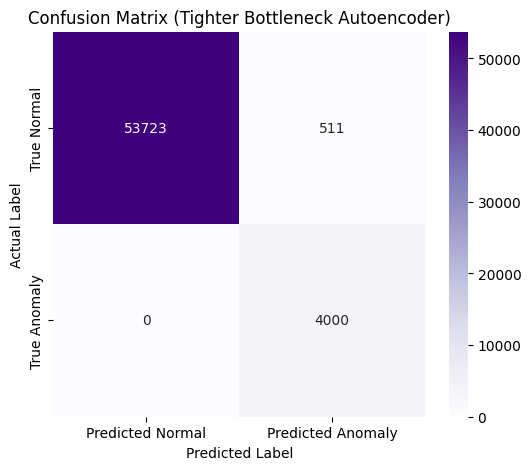

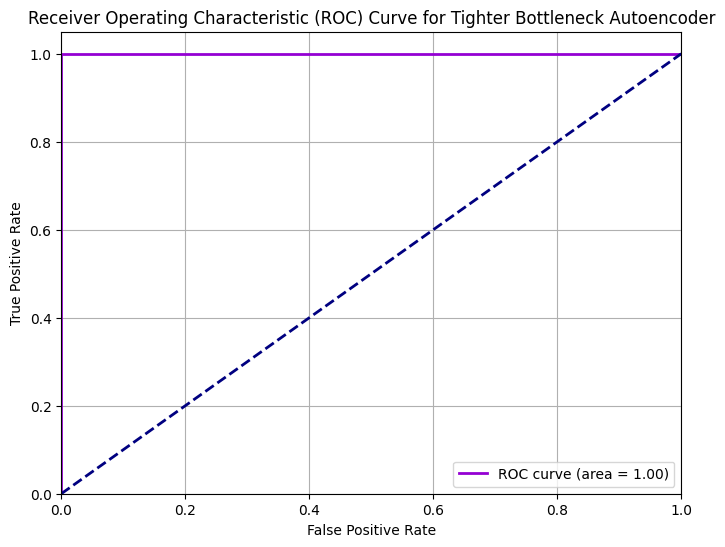

ROC AUC (Tighter Bottleneck): 1.0000

--- Sweeping different percentile thresholds (based on validation set for tighter bottleneck) ---
P90 | threshold=0.1164 | precision=0.425 | recall=1.000
P92 | threshold=0.1348 | precision=0.480 | recall=1.000
P95 | threshold=0.1750 | precision=0.600 | recall=1.000
P97 | threshold=0.2353 | precision=0.720 | recall=1.000
P99 | threshold=0.4044 | precision=0.887 | recall=1.000


In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, roc_curve, auc, classification_report
import seaborn as sns

# Apply the 99th percentile threshold from the tighter bottleneck model
threshold_tighter = threshold_99_percentile_tighter # Using the threshold derived from the validation set for tighter model

# Classify instances as normal (0) or anomaly (1) based on the threshold
# If reconstruction error > threshold, it's an anomaly (1)
predictions_full_tighter = (reconstruction_errors_full_tighter > threshold_tighter).astype(int)

print(f"Anomaly Threshold (99th percentile from validation set for tighter bottleneck): {threshold_tighter:.4f}")

# Evaluate performance
# Confusion Matrix
cm_tighter = confusion_matrix(y_full_binary, predictions_full_tighter)
print("\n--- Confusion Matrix (Tighter Bottleneck Autoencoder) ---")
print(cm_tighter)

# Precision, Recall, F1-score
precision_tighter, recall_tighter, f1_score_tighter, _ = precision_recall_fscore_support(y_full_binary, predictions_full_tighter, average='binary')
print(f"Precision (Tighter Bottleneck): {precision_tighter:.4f}")
print(f"Recall (Tighter Bottleneck): {recall_tighter:.4f}")
print(f"F1-Score (Tighter Bottleneck): {f1_score_tighter:.4f}")

print("\n--- Classification Report (Tighter Bottleneck Autoencoder) ---")
print(classification_report(y_full_binary, predictions_full_tighter, target_names=['Normal', 'Anomaly']))

# Optional: Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tighter, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['True Normal', 'True Anomaly'])
plt.title('Confusion Matrix (Tighter Bottleneck Autoencoder)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve and AUC
fpr_tighter, tpr_tighter, thresholds_roc_tighter = roc_curve(y_full_binary, reconstruction_errors_full_tighter)
roc_auc_tighter = auc(fpr_tighter, tpr_tighter)

plt.figure(figsize=(8, 6))
plt.plot(fpr_tighter, tpr_tighter, color='darkviolet', lw=2, label=f'ROC curve (area = {roc_auc_tighter:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tighter Bottleneck Autoencoder')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC AUC (Tighter Bottleneck): {roc_auc_tighter:.4f}")

print("\n--- Sweeping different percentile thresholds (based on validation set for tighter bottleneck) ---")
for pct in [90, 92, 95, 97, 99]:
    # Use the reconstruction errors from the *validation* data to set the threshold
    threshold_current_pct_tighter = np.percentile(reconstruction_errors_tighter, pct)
    # Apply this threshold to the reconstruction errors of the *full dataset*
    preds_current_pct_tighter = (reconstruction_errors_full_tighter > threshold_current_pct_tighter).astype(int)
    recall = recall_score(y_full_binary, preds_current_pct_tighter)
    precision = precision_score(y_full_binary, preds_current_pct_tighter)
    print(f"P{pct} | threshold={threshold_current_pct_tighter:.4f} | precision={precision:.3f} | recall={recall:.3f}")

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

# Using existing variables from previous cells
# X_full_scaled: the scaled full dataset
# y_full_binary: the binary labels for the full dataset
# autoencoder_tighter: the newly trained autoencoder model with tighter bottleneck
# threshold_tighter: the 99th percentile threshold from validation data for the tighter model

n_splits = 20 # Number of folds for cross-validation
skf_tighter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold for the tighter model
precision_scores_tighter = []
recall_scores_tighter = []
f1_scores_tighter = []

print(f"Performing {n_splits}-fold cross-validation on the full dataset for the tighter bottleneck autoencoder...")

for fold, (train_idx_cv, test_idx_cv) in enumerate(skf_tighter.split(X_full_scaled, y_full_binary)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    X_test_fold_tighter = X_full_scaled.iloc[test_idx_cv]
    y_test_fold_tighter = y_full_binary.iloc[test_idx_cv]

    # Predict reconstructions for the current test fold using the already trained autoencoder_tighter
    X_test_reconstructed_fold_tighter = autoencoder_tighter.predict(X_test_fold_tighter, verbose=0)

    # Calculate reconstruction errors for the test fold
    reconstruction_errors_fold_tighter = np.mean(np.square(X_test_fold_tighter - X_test_reconstructed_fold_tighter), axis=1)

    # Apply the pre-determined anomaly threshold (using threshold_tighter, which is 99th percentile from validation)
    predictions_fold_tighter = (reconstruction_errors_fold_tighter > threshold_tighter).astype(int)

    # Calculate and store metrics
    precision_t = precision_score(y_test_fold_tighter, predictions_fold_tighter)
    recall_t = recall_score(y_test_fold_tighter, predictions_fold_tighter)
    f1_t = f1_score(y_test_fold_tighter, predictions_fold_tighter)
    conf_matrix_t = confusion_matrix(y_test_fold_tighter, predictions_fold_tighter)

    precision_scores_tighter.append(precision_t)
    recall_scores_tighter.append(recall_t)
    f1_scores_tighter.append(f1_t)

    print(f"Precision: {precision_t:.4f}")
    print(f"Recall: {recall_t:.4f}")
    print(f"F1-Score: {f1_t:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix_t}")

# Print average metrics across all folds for the tighter model
print("\n--- Average Metrics Across All Folds (Tighter Bottleneck Autoencoder) ---")
print(f"Average Precision: {np.mean(precision_scores_tighter):.4f} (+/- {np.std(precision_scores_tighter):.4f})")
print(f"Average Recall: {np.mean(recall_scores_tighter):.4f} (+/- {np.std(recall_scores_tighter):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores_tighter):.4f} (+/- {np.std(f1_scores_tighter):.4f})")

Performing 20-fold cross-validation on the full dataset for the tighter bottleneck autoencoder...

--- Fold 1/20 ---
Precision: 0.8929
Recall: 1.0000
F1-Score: 0.9434
Confusion Matrix:
[[2688   24]
 [   0  200]]

--- Fold 2/20 ---
Precision: 0.9050
Recall: 1.0000
F1-Score: 0.9501
Confusion Matrix:
[[2691   21]
 [   0  200]]

--- Fold 3/20 ---
Precision: 0.8850
Recall: 1.0000
F1-Score: 0.9390
Confusion Matrix:
[[2686   26]
 [   0  200]]

--- Fold 4/20 ---
Precision: 0.8734
Recall: 1.0000
F1-Score: 0.9324
Confusion Matrix:
[[2683   29]
 [   0  200]]

--- Fold 5/20 ---
Precision: 0.8969
Recall: 1.0000
F1-Score: 0.9456
Confusion Matrix:
[[2689   23]
 [   0  200]]

--- Fold 6/20 ---
Precision: 0.8889
Recall: 1.0000
F1-Score: 0.9412
Confusion Matrix:
[[2687   25]
 [   0  200]]

--- Fold 7/20 ---
Precision: 0.8850
Recall: 1.0000
F1-Score: 0.9390
Confusion Matrix:
[[2686   26]
 [   0  200]]

--- Fold 8/20 ---
Precision: 0.8772
Recall: 1.0000
F1-Score: 0.9346
Confusion Matrix:
[[2684   28]
 [  

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- START: Required Data Loading and Preprocessing to define X_train and X_val ---
# This block is added to ensure X_train and X_val are available if previous cells were not run.

# 1. Load data (from tsGQ9cz1W8p0)
# Assuming data_1 is loaded from the specified path.
# If data_1 is already globally available and correct, this line can be commented out.
data_1 = pd.read_csv("/content/drive/MyDrive/Grad project/dataset_v4_master_training.csv", low_memory=False)

# 2. Filter out attacks for initial training (from CPKz92MYYo1L)
data_1_noAttacks = data_1[~data_1['label'].isin([1, 2])].copy() # .copy() to avoid SettingWithCopyWarning

# 3. Drop irrelevant features (from 82hf3vJRZ-zc)
features_to_drop_stage1 = [
  'timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'top_dst_port',
  'snort_sid', 'active_snort_alerts', 'distinct_alert_types',
]
data_1_noAttacks.drop(columns=features_to_drop_stage1, axis=1, errors='ignore', inplace=True)

# 4. Drop more unneeded features (from 1407H8uQaBPI)
features_to_drop_stage2 = [
  "incomplete_ratio", "packets_per_second", "total_bytes", "device_pkt_rate_deviation",
  "is_broadcast_dst", "arp_reply_request_ratio", "device_byte_rate_deviation",
  "arp_gratuitous_count", "inter_arrival_std", "is_registered_iot",
  "ip_mac_binding_changes", "rst_count", "arp_unsolicited_count",
  "well_known_port_ratio", "device_pkt_rate_deviation", "burst_duration_avg",
  "broadcast_ratio", "arp_reply_rate", "burst_count", "psh_count",
  "device_unique_dst_ips", "mac_ip_binding_changes", "device_avg_byte_rate",
  "device_age_seconds", "network_avg_flow_duration", "inter_arrival_max",
  "dst_port_std", "inter_arrival_min",
]
data_1_noAttacks.drop(columns=features_to_drop_stage2, axis=1, errors='ignore', inplace=True)

# 5. One-Hot Encode (from gA6aORvwaDrY)
data_1_noAttacks_encoded = pd.get_dummies(data_1_noAttacks, prefix='protocol')

# 6. Separate features and labels (from EWpnRDrvaIP6)
x = data_1_noAttacks_encoded.drop('label', axis=1)
x.drop('attack_type', axis=1 , errors = "ignore", inplace=True)
y = data_1_noAttacks_encoded['label']

# 7. Standardize Data (from ATDvmyGgaLUo)
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns, index=x.index)

nan_rows_after_scaling = x_scaled.isnull().any(axis=1) | y.isnull()
if nan_rows_after_scaling.any():
    # print(f"Found {nan_rows_after_scaling.sum()} rows with NaN values in x_scaled or y after scaling. Dropping them.")
    x_scaled = x_scaled[~nan_rows_after_scaling]
    y = y[~nan_rows_after_scaling]

# 8. Split Data (from UCQIMUtjaOpP)
X_train, X_val, y_train, y_val = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)
# --- END: Required Data Loading and Preprocessing ---


# Re-define the input dimension based on X_train shape
input_dim = X_train.shape[1]
latent_dim_tighter = 16 # Tighter bottleneck dimension

# Encoder for the tighter bottleneck autoencoder
input_layer_tighter = Input(shape=(input_dim,))
encoder_tighter = Dense(64, activation='relu')(input_layer_tighter)
encoder_tighter = Dense(latent_dim_tighter, activation='relu')(encoder_tighter)

# Decoder for the tighter bottleneck autoencoder
decoder_tighter = Dense(64, activation='relu')(encoder_tighter)
decoder_tighter = Dense(input_dim, activation='linear')(decoder_tighter)

# Tighter Bottleneck Autoencoder Model
autoencoder_tighter = Model(inputs=input_layer_tighter, outputs=decoder_tighter)

# Compile the autoencoder with a reduced learning rate
autoencoder_tighter.compile(optimizer=Adam(learning_rate=0.0001), loss='mse')

# Train the tighter bottleneck autoencoder
print("Re-training tighter bottleneck autoencoder for saving...")
history_tighter = autoencoder_tighter.fit(X_train, X_train, # Input and target are the same for autoencoders
                                        epochs=50,
                                        batch_size=128,
                                        shuffle=True,
                                        validation_data=(X_val, X_val),
                                        verbose=0) # Set verbose to 1 or 2 for progress output
print("Tighter bottleneck autoencoder re-training complete.")

# Define the directory and filename for saving the model
model_save_dir = '/content/saved_models'
model_filename = 'autoencoder_tighter_bottleneck_16units.h5'
model_save_path = os.path.join(model_save_dir, model_filename)

# Create the directory if it doesn't exist
os.makedirs(model_save_dir, exist_ok=True)

# Save the autoencoder model
autoencoder_tighter.save(model_save_path)

print(f"Tighter bottleneck autoencoder model saved successfully to: {model_save_path}")

Re-training tighter bottleneck autoencoder for saving...


Tighter bottleneck autoencoder re-training complete.
Tighter bottleneck autoencoder model saved successfully to: /content/saved_models/autoencoder_tighter_bottleneck_16units.h5
